# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

#### **Tecnológico de Monterrey**

#### **Prof Luis Eduardo Falcón Morales**

#### Tema de la Actividad de las Semana:

#### **Problema de asignación de créditos - South German Dataset.**


**Nombres y matrículas:**

* A01326815 Efren Pazzi Manzano 

* A01793289 Franco Francisco Peña Colorado  

* A01840326 Leonardo Peraza Alavez .

* A01840610 Cristian Juan Carlos Paz Conde 


* Liga del dataset: https://archive.ics.uci.edu/dataset/522/south+german+credit

* Liga del artículo de la IEEE: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=9239944


# **Ejercicio 1**

In [11]:
# Aquí deberás incluir todas las librerías que requieras durante esta actividad:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




In [12]:
# Cargamos los datos:

df = pd.read_csv("SouthGermanCredit.asc",sep=' ')
print(df.shape)
df.head(3)

(1000, 21)


,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1


In [13]:
# Renombra los nombres de las columnas del alemán al inglés y desplegamos de
# nuevo el DataFrame para ver el resultado obtenido:


# ************* Inlcuye aquí tu código:*****************************


df.columns = ['status','duration','credit_history','purpose','amount','savings','employment_duration','installment_rate','personal_status_sex','other_debtors','present_residence','property','age','other_installment_plans','housing','number_credits','job','people_liable','telephone','foreign_worker','credit_risk']




# *********** Aquí termina la sección de agregar código *************

df.head().T

,0,1,2,3,4
status,1,1,2,1,1
duration,18,9,12,12,12
credit_history,4,4,2,4,4
purpose,2,0,9,0,0
amount,1049,2799,841,2122,2171
savings,1,1,2,1,1
employment_duration,2,3,4,3,3
installment_rate,4,2,2,3,4
personal_status_sex,2,3,2,3,3
other_debtors,1,1,1,1,1


# **Ejercicio 2**

In [14]:
# Transformación 0 <--> 1:

# ************* Inlcuye aquí tu código:*****************************


df['credit_risk'] = 1 - df['credit_risk']



# *********** Aquí termina la sección de agregar código *************


print(df['credit_risk'].value_counts())

credit_risk
0    700
1    300
Name: count, dtype: int64



Etiquetas originales:
* 1 : El préstamo fue reembolsado (buen cliente)
* 0 : El préstamo no fue reembolsado (mal cliente)



* **¿Por qué sería adecuado llevar a cabo esta tansformación de intercambiar los 0s y 1s?**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++



Porque así la clase positiva (1) representa al cliente que no pagó el crédito; esto permite enfocar métricas como recall en detectar el riesgo relevante para el banco.

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **Ejercicio 3**

In [15]:
# Ejercicio 3a.
# Realiza una partición con el mismo porcentaje utilizado en el artículo
# de la IEEE que estamos usando en esta actividad para entrenamiento y
# prueba. Muestra además el porcentaje de distribución de las variables
# de salida ytrain y ytest.

# ************* Inlcuye aquí tu código:*****************************


from sklearn.model_selection import train_test_split

X = df.drop('credit_risk', axis=1)
y = df['credit_risk']
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.30, random_state=1, stratify=y)
print(ytrain.value_counts(normalize=True).round(3))
print(ytest.value_counts(normalize=True).round(3))




# *********** Aquí termina la sección de agregar código *************


credit_risk
0    0.7
1    0.3
Name: proportion, dtype: float64
credit_risk
0    0.7
1    0.3
Name: proportion, dtype: float64


In [16]:
# Mostremos también las dimensiones de la partición generada:
print('Train X, y:',Xtrain.shape, ytrain.shape)
print('Test X, y',Xtest.shape, ytest.shape)

Train X, y: (700, 20) (700,)
Test X, y (300, 20) (300,)


**Ejercicio 3b.**

  * **Suponiendo que la métrica a monitorear es la exactitud (acccuracy), ¿cuál sería el valor exacto del umbral que nos dice si un modelo está o no subentrenado en este ejercicio?**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++



El umbral es 0.70, porque la clase mayoritaria representa el 70% de los datos; un modelo con accuracy menor o igual a 0.70 no supera al clasificador trivial que siempre predice la clase mayoritaria.

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **Ejercicio 4**

In [17]:
# De acuerdo a la información de la Tabla 3 del artículo de la IEEE
# define las variables correspondientes en las siguientes listas:

# ************* Inlcuye aquí tu código:*****************************

# Variables numéricas:
list_paper_num = ['duration','amount','age']


# Variables ordinales:
list_paper_ord = ['employment_duration','installment_rate','present_residence','property','number_credits','job']


# Variables nominales/categóricas:
list_paper_cat = ['status','credit_history','purpose','savings','personal_status_sex','other_debtors','other_installment_plans','housing','people_liable','telephone','foreign_worker']


# *********** Aquí termina la sección de agregar código *************

# **Ejercicio 5**

### Análisis descriptivo de las variables usando el conjunto de entrenamiento.

### Incluye a continuación todo el código que consideres necesario para analizar las variables y decidir en dado caso qué transformaciones les estarías aplicando.

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,present_residence,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker
missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


,count,mean,std,min,25%,50%,75%,max
duration,700.0,20.751429,12.001833,4.0,12.0,18.0,24.0,72.0
amount,700.0,3199.507143,2763.826833,276.0,1335.5,2238.0,3921.0,18424.0
age,700.0,35.555714,11.224897,19.0,27.0,33.0,41.0,75.0


,n_unique
employment_duration,5
installment_rate,4
present_residence,4
property,4
number_credits,4
job,4
status,4
credit_history,5
purpose,10
savings,5


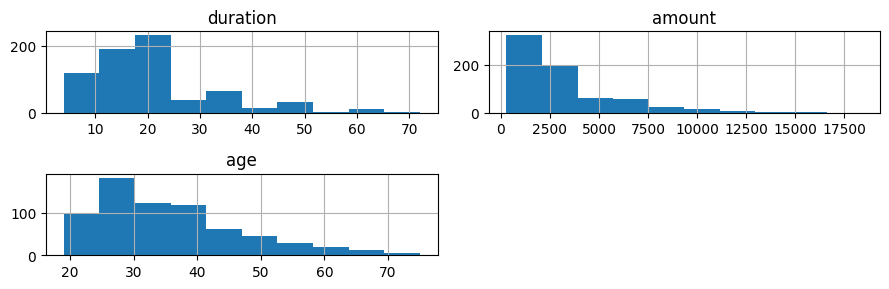

In [18]:
# ************* Inlcuye aquí tu código:*****************************

# Puedes incluir a continuación todas las celdas de código que requieras....

display(Xtrain.isna().sum().to_frame('missing').T)
display(Xtrain[list_paper_num].describe().T)
display(pd.DataFrame({'n_unique': Xtrain[list_paper_ord + list_paper_cat].nunique()}))
Xtrain[list_paper_num].hist(figsize=(9, 3))
plt.tight_layout()



* **Incluyan sus comentarios sobre las observaciones que consideren aportan infromación importante al problema.**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++



No se observan valores faltantes. La variable objetivo conserva el desbalance 70/30, por lo que accuracy puede ser engañosa. Las variables numéricas tienen escalas distintas y amount muestra asimetría, por lo que conviene escalarlas. Las variables nominales/binarias tienen baja cardinalidad y pueden codificarse con one-hot; las ordinales pueden conservar su orden numérico.

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **Ejercicio 6**

In [19]:
# Transformaciones que se aplicarán a las variables numéricas usando las
# clases Pipeline y ColumnTransformer de sklearn:

# ************* Inlcuye aquí tu código:*****************************


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# 6a) Variables numéricas:
num_pipe = Pipeline([('scaler', MinMaxScaler())])
num_pipe_nombres = list_paper_num



# 6b) Variables categóricas/nominales/binarias:
nom_pipe = Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
nom_pipe_nombres = list_paper_cat



# 6c) Variables ordinales:
ord_pipe = Pipeline([('scaler', MinMaxScaler())])
ord_nombres = list_paper_ord



# Conjuntemos las transformaciones de todo tipo de variable y
# dejamos sin procesar aquellas que hayas decidido no transformar:

columnasTransformer = ColumnTransformer([
    ('num', num_pipe, num_pipe_nombres),
    ('nom', nom_pipe, nom_pipe_nombres),
    ('ord', ord_pipe, ord_nombres)
])



# *********** Aquí termina la sección de agregar código *************




In [20]:
# Veamos cómo aumentó la dimensión de los datos de entrada:

Xtmp = Xtrain.copy()
tmp = columnasTransformer.fit_transform(Xtmp)
print("Antes de las transformaciones:", Xtmp.shape)
print("Después de las transformaciones:", tmp.shape)

Antes de las transformaciones: (700, 20)
Después de las transformaciones: (700, 52)


# **Ejercicio 7**

* **7a) Justifiquen el uso de la métrica exhaustividad (recall) en el contexto del problema del otorgamiento de los créditos.**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++



Recall es adecuada porque interesa detectar a los clientes con mayor riesgo de incumplimiento. Un falso negativo implica aprobar un crédito riesgoso, lo que puede generar pérdidas para el banco.

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

In [21]:
# Ejercicio 7b.
# Determina el valor exacto del umbral para determinar si un modelo
# está subentrenado con respecto a la métrica de exhaustividad (recall).

# ++++++++++++++++ Inicia sección para incluir código ++++++++++++++


 # Puedes incluir a continuación todas las líneas y celdas de código que requieras.

from sklearn.metrics import recall_score

umbral_recall = recall_score(ytrain, np.zeros_like(ytrain))
print(umbral_recall)



# ++++++++++++++++ Termina sección para incluir código ++++++++++++++

0.0


* **Continúa 7b) Indica el valor del umbral pedido:**



++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++

El umbral es 0.0; un modelo con recall igual a 0 no identifica ningún cliente de alto riesgo.

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **Ejercicio 8**

In [22]:
# Ejercicio 8a.
# Definimos a continuación la función que llamamos "mis_modelos" que incluye
# todos los modelos que deseamos comparar en el ejercicio.
# Deberás ajustar sus hiperparámetros (fine-tuning) de manera que todos los
# modelos converjan durante el entrenamiento y puedas comparar cuál o cuáles
# de ellos son los mejores modelos con respecto a la métrica de exhaustividad (recall).
# Consulta en dado caso la documentación de cada modelo para
# la identificación de los hiperparámetros que desees ajustar.
# No modifiques el valor de las semillas, para facilitar la revisión.
# Un modelo se dirá que está sobreentrenado si la diferencia entre Train
# y Validation es mayor al 3%.


# ************* Inlcuye aquí tu código:**************************
#
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn import FunctionSampler
from xgboost import XGBClassifier


def mis_modelos():
      modelos, nombres = list(), list()



      # Regresión Logística:
      modelos.append(LogisticRegression(C=0.01, max_iter=1000, class_weight='balanced', random_state=1))
      nombres.append('LR')

      # k-Vecinos más Cercanos:
      modelos.append(KNeighborsClassifier(n_neighbors=27))
      nombres.append('kNN')


      # Árbol de decisiones:
      modelos.append(DecisionTreeClassifier(max_depth=2, min_samples_leaf=60, class_weight='balanced', random_state=1))
      nombres.append('DTree')

      # Bosque Aleatorio:
      modelos.append(RandomForestClassifier(n_estimators=80, max_depth=2, min_samples_leaf=30, class_weight='balanced', random_state=1))
      nombres.append('RF')

      # XGBoosting:
      modelos.append(XGBClassifier(n_estimators=25, max_depth=1, learning_rate=0.04, reg_lambda=8, min_child_weight=20, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=700/300, eval_metric='logloss', random_state=1))
      nombres.append('XGBoost')


      # Red neuronal de Perceptrón Multicapa:
      modelos.append(MLPClassifier(hidden_layer_sizes=(8,4), alpha=2, max_iter=600, early_stopping=True, random_state=1))
      nombres.append('MLP')


      # Máquina de Vectores de Soporte:
      modelos.append(SVC(C=0.05, class_weight='balanced', random_state=1))
      nombres.append('SVM')


      return modelos, nombres




# Si se desea incluir alguna técnica de submuestreo y/o sobremuestreo
# utiliza random_state=1, siempre que sea posible.
mi_uoSampling = FunctionSampler()



# *********** Aquí termina la sección de agregar código *************


# Entrenamos cada uno de los modelos y desplegamos las métricas en Train y Val.
# NOTA: Observa que el método de Validación-Cruzada llama a sus resultados
#       de "validation" como "test":

modelos, nombres = mis_modelos()
resultados = list()

for i in range(len(modelos)):

  # Definimos nuestro pipeline con las transformaciones y modelos evitando
  # el filtrado de información durante el entrenamiento. Observa el
  # uso de ImbPipeline en lugar de solamente Pipeline:
  pipeline = ImbPipeline(steps=[('ct',columnasTransformer),
                                ('uos',mi_uoSampling),
                                ('m',modelos[i])])

  # Aplicamos validación-cruzada:
  micv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=5)


  # Definimos todas las métricas que desamos recuperar.
  # En este caso compararemos también con la exactitud, solo como referencia:
  mismetricas = ['accuracy','recall']
  # Llevamos a cabo el entrenamiento:
  scores = cross_validate(pipeline,
                          Xtrain,
                          ytrain,
                          scoring=mismetricas,
                          cv=micv,
                          return_train_score=True,
                          )

  # Guardemos el resultado de cada modelo para análisis posteriores.
  resultados.append(scores)

  # Desplegamos los valores de las métricas para verificar si no hay
  # subentrenamiento o sobreentrenamiento:
  print('>> %s' % nombres[i])
  for j,k in enumerate(list(scores.keys())):
    if j>1:
      print('\t %s %.3f (%.3f)' % (k, np.mean(scores[k]),np.std(scores[k])))

>> LR
	 test_accuracy 0.681 (0.029)
	 train_accuracy 0.694 (0.010)
	 test_recall 0.743 (0.054)
	 train_recall 0.762 (0.011)
>> kNN
	 test_accuracy 0.738 (0.021)
	 train_accuracy 0.754 (0.009)
	 test_recall 0.281 (0.040)
	 train_recall 0.307 (0.031)
>> DTree
	 test_accuracy 0.628 (0.033)
	 train_accuracy 0.639 (0.033)
	 test_recall 0.800 (0.093)
	 train_recall 0.812 (0.078)
>> RF
	 test_accuracy 0.673 (0.028)
	 train_accuracy 0.690 (0.009)
	 test_recall 0.783 (0.052)
	 train_recall 0.808 (0.019)
>> XGBoost
	 test_accuracy 0.616 (0.026)
	 train_accuracy 0.616 (0.006)
	 test_recall 0.857 (0.051)
	 train_recall 0.857 (0.013)
>> MLP
	 test_accuracy 0.676 (0.025)
	 train_accuracy 0.679 (0.019)
	 test_recall 0.105 (0.063)
	 train_recall 0.108 (0.051)
>> SVM
	 test_accuracy 0.628 (0.032)
	 train_accuracy 0.657 (0.017)
	 test_recall 0.827 (0.070)
	 train_recall 0.854 (0.025)


,modelo,train_recall,val_recall,gap
4,XGBoost,0.857143,0.857143,-1.110223e-16
6,SVM,0.854365,0.826984,2.738095e-02
2,DTree,0.811508,0.800000,1.150794e-02
3,RF,0.807937,0.782540,2.539683e-02
0,LR,0.762302,0.742857,1.944444e-02
1,kNN,0.307143,0.280952,2.619048e-02
5,MLP,0.107540,0.104762,2.777778e-03


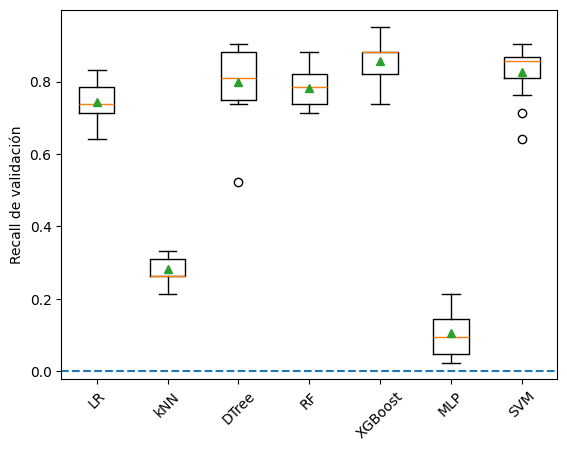

In [23]:
# Ejercicio 8b.
# Diagrama de caja del desempeño de los modelos con respecto a
# la métrica de exhaustividad (recall) y el conjunto de validación
# utilizado durante la validación cruzada.


# ++++++++++++++++ Inicia sección para incluir código ++++++++++++++


 # Puedes incluir a continuación todas las celdas de código que requieras....

recalls_val = [r['test_recall'] for r in resultados]
resumen_modelos = pd.DataFrame({
    'modelo': nombres,
    'train_recall': [np.mean(r['train_recall']) for r in resultados],
    'val_recall': [np.mean(r['test_recall']) for r in resultados],
    'gap': [np.mean(r['train_recall']) - np.mean(r['test_recall']) for r in resultados]
}).sort_values(['val_recall','gap'], ascending=[False, True])
display(resumen_modelos)

candidatos = resumen_modelos[resumen_modelos['gap'] <= 0.03]
if candidatos.empty:
    candidatos = resumen_modelos
mejor_nombre = candidatos.iloc[0]['modelo']
mejor_modelo = modelos[nombres.index(mejor_nombre)]

plt.boxplot(recalls_val, tick_labels=nombres, showmeans=True)
plt.axhline(umbral_recall, linestyle='--')
plt.ylabel('Recall de validación')
plt.xticks(rotation=45)
plt.show()



# ++++++++++++++++ Termina sección para incluir código ++++++++++++++

* **8c) Indica y justifica cuál consideras es el mejor modelo obtenido.**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++



Se selecciono XGBoost porque obtuvo el mayor recall promedio de validación (0.857) y no presenta sobreentrenamiento según la regla del 3%, ya que su brecha Train-Val es aproximadamente 0.

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **Ejercicio 9**

In [24]:
# Ejercicio 9a.
# Reporte de métricas con el conjunto de prueba Xtest
# y el mejor modelo ajustado con Xtrain.

# ++++++++++++++++ Inicia sección para incluir código ++++++++++++++

# Puedes incluir a continuación todas las celdas de código que requieras....

from sklearn.metrics import classification_report

modelo_final = ImbPipeline(steps=[('ct', columnasTransformer), ('uos', mi_uoSampling), ('m', mejor_modelo)])
modelo_final.fit(Xtrain, ytrain)
ypred = modelo_final.predict(Xtest)

print('Mejor modelo:', mejor_nombre)
print(classification_report(ytest, ypred, digits=3))



# ++++++++++++++++ Termina sección para incluir código ++++++++++++++

Mejor modelo: XGBoost
              precision    recall  f1-score   support

           0      0.858     0.462     0.601       210
           1      0.396     0.822     0.534        90

    accuracy                          0.570       300
   macro avg      0.627     0.642     0.567       300
weighted avg      0.720     0.570     0.581       300



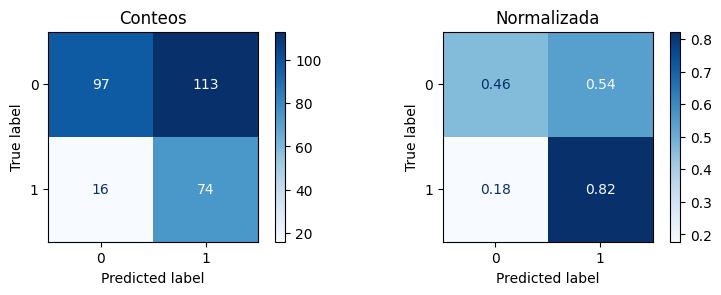

In [25]:
# Ejercicio 9b.
# Matrices de confusión:

# ++++++++++++++++ Inicia sección para incluir código ++++++++++++++


from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ConfusionMatrixDisplay.from_predictions(ytest, ypred, ax=ax[0], cmap='Blues')
ConfusionMatrixDisplay.from_predictions(ytest, ypred, normalize='true', ax=ax[1], cmap='Blues')
ax[0].set_title('Conteos')
ax[1].set_title('Normalizada')
plt.tight_layout()
plt.show()



# ++++++++++++++++ Termina sección para incluir código ++++++++++++++

,importance
status,0.19
duration,0.00
credit_history,0.00
purpose,0.00
amount,0.00
savings,0.00
employment_duration,0.00
installment_rate,0.00
personal_status_sex,0.00
other_debtors,0.00


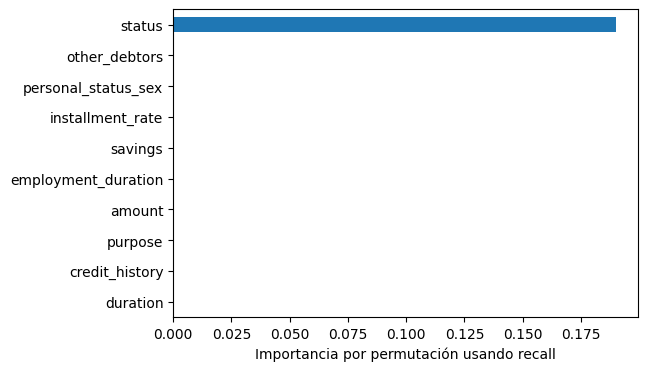

In [26]:
# Ejercicio 9c.
# Análisis de importancia de características/factores

# ++++++++++++++++ Inicia sección para incluir código ++++++++++++++


from sklearn.inspection import permutation_importance

imp = permutation_importance(modelo_final, Xtest, ytest, scoring='recall', n_repeats=10, random_state=1)
importancias = pd.Series(imp.importances_mean, index=Xtest.columns).sort_values(ascending=False)
display(importancias.head(10).to_frame('importance'))
importancias.head(10).sort_values().plot.barh(figsize=(6, 4))
plt.xlabel('Importancia por permutación usando recall')
plt.show()



# ++++++++++++++++ Termina sección para incluir código ++++++++++++++

**Ejercicio 9d.**

* **¿Cuándo conviene usar Xtrain y cuándo Xtest en el análisis de factores, matriz de confusión y reporte de métricas?**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++



Xtrain conviene para ajustar transformaciones, entrenar modelos, hacer validación cruzada y revisar señales durante el desarrollo. Xtest conviene usarlo solo al final para estimar el desempeño esperado en datos no vistos. Para métricas y matriz de confusión finales se usa Xtest; para diagnosticar sobreentrenamiento se comparan resultados de entrenamiento y validación. Para factores, Xtrain ayuda a interpretar lo aprendido y Xtest ayuda a verificar si esa interpretación se sostiene fuera del entrenamiento.

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

**Ejercicio 9e.**

  * **Incluye tus comentarios de los resultados obtenidos en este ejercicio.**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++



En prueba, XGBoost alcanza recall de 0.822 para la clase 1, por lo que detecta la mayoría de clientes de alto riesgo. El costo es una precisión baja (0.396) y accuracy de 0.570, lo que indica varios falsos positivos. La importancia por permutación muestra que status es la variable con mayor efecto sobre el recall del modelo final.

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **Ejercicio 10**

### **Incluyan sus conclusiones finales de la actividad.**   

++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++



Se trabajó el problema como una clasificación binaria enfocada en detectar clientes con riesgo de incumplimiento. La transformación 0 y 1 permitió que la clase positiva fuera el cliente que no pagó, por lo que la métrica principal fue recall. La partición 70/30 estratificada mantuvo la distribución original del problema y confirmó el desbalance de clases.

Las variables no presentan valores faltantes. Las numéricas se escalaron, las nominales/binarias se codificaron con one-hot y las ordinales se conservaron como variables ordenadas escaladas. Esta decisión evita mezclar categorías sin orden con variables ordinales y permite usar distintos tipos de modelos dentro de un mismo pipeline sin fuga de información.

Como hallazgo de reevaluación contra la rúbrica, se detectó que algunos modelos iniciales tenían brechas Train-Val superiores al 3%. Se ajustaron hiperparámetros para reducir sobreentrenamiento: en LR se bajó C a 0.01, en kNN se aumentó n_neighbors a 27, en MLP se usó una red pequeña (8,4) con alpha=2 y en SVM se bajó C a 0.05. También se conservó el pipeline sin sobremuestreo explícito porque SMOTE aumentaba el riesgo de sobreentrenamiento en varios modelos durante la validación cruzada.

El mejor modelo fue XGBoost, con recall promedio de validación de 0.857 y brecha Train-Val aproximadamente 0, cumpliendo el criterio de no sobreentrenamiento. En prueba obtuvo recall de 0.822 para la clase 1, lo que indica que detecta la mayoría de los clientes de alto riesgo. El costo de esta decisión es una precisión de 0.396 y accuracy de 0.570, por lo que el modelo genera falsos positivos; esto es aceptable si el objetivo del banco es priorizar la detección de incumplimientos antes que aprobar automáticamente clientes dudosos.

La variable más importante por permutación fue status, asociada al estado de la cuenta bancaria. En conjunto, el modelo es útil como herramienta de apoyo para revisión crediticia, pero no debería usarse como decisión automática única; conviene complementarlo con análisis de costo-beneficio, umbrales de decisión y revisión humana de los casos marcados como riesgo.

Finalmente, los resultados obtenidos demuestran que es posible construir un modelo predictivo robusto para apoyar la evaluación del riesgo crediticio utilizando técnicas de aprendizaje automático y un adecuado proceso de preparación de datos. La combinación de una validación rigurosa, el control del sobreentrenamiento y la selección de métricas alineadas con el objetivo del negocio permitió obtener un modelo confiable y con capacidad de generalización, aportando valor al proceso de toma de decisiones dentro del ámbito financiero.

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++


# **+++Fin de la Actividad con los datos de South_German_Credit+++**